In [28]:
# Libraries
import sys
sys.path.append("..")
from src.utils import section

import matplotlib.pyplot as plt


In [25]:
from src.data_load import data_loader

# Load data
df = data_loader("../data/raw/ecommerce_return_classification.csv")
df.head()

,cart_value_usd,past_return_rate,size_bracketing_flag,delivery_days_taken,discount_pct_applied,product_category,fit_review_sentiment,newsletter_subscriber,browser_used,checkout_device,packaging_color,loyalty_card_color,return_risk_label
0,172.17,0.233,1,11,10,Footwear,True-to-Size,1,Safari,Android-App,Kraft-Brown,Platinum,1
1,213.55,0.235,1,6,40,Accessories,True-to-Size,0,Firefox,Android-App,Branded-Teal,Silver,0
2,371.70,0.461,1,11,40,Formal-Eveningwear,True-to-Size,0,Firefox,iOS-App,Kraft-Brown,Gold,1
3,317.18,0.080,0,1,20,Footwear,Inconsistent-Sizing,0,Firefox,iOS-App,Kraft-Brown,Gold,1
4,152.68,0.133,0,3,40,Accessories,True-to-Size,0,Edge,iOS-App,Branded-Teal,Silver,0


                                        
AFTER IMPUATION OF OUTLIERS:


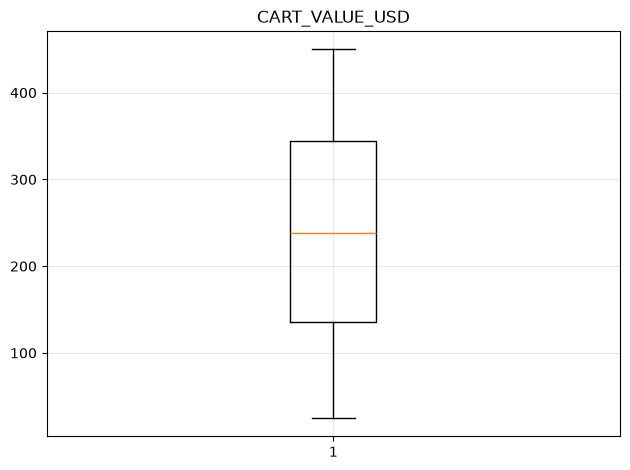

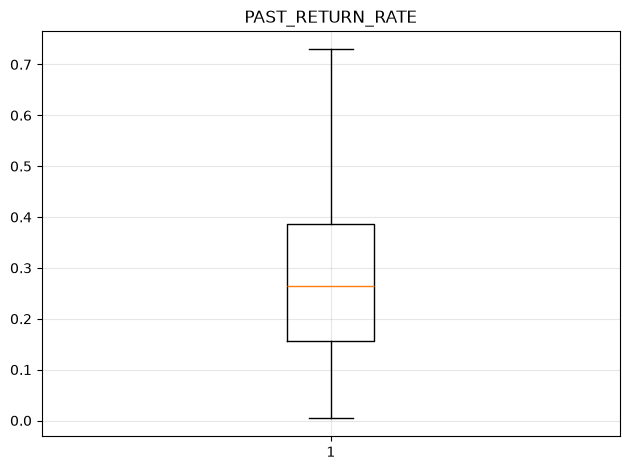

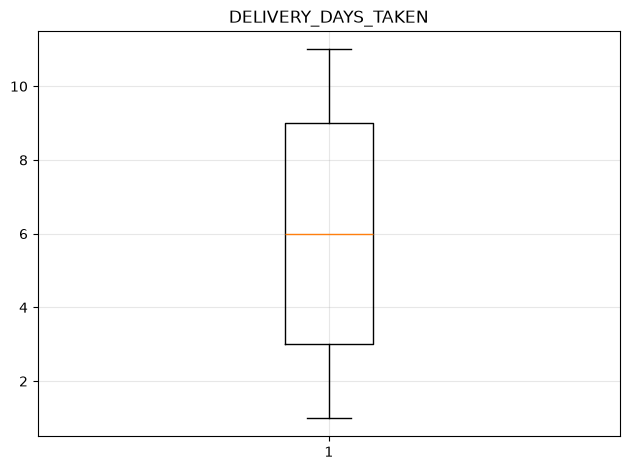

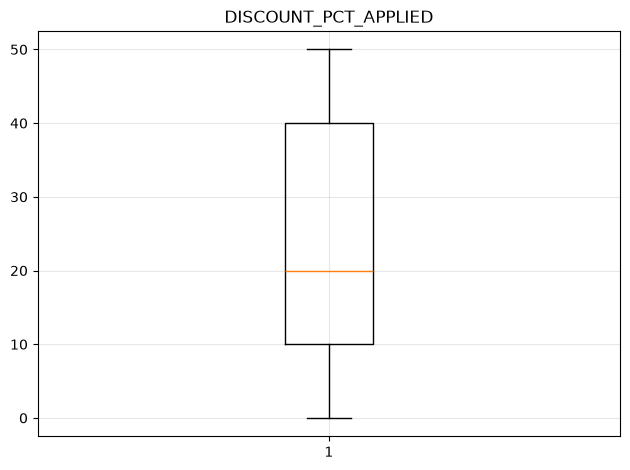

In [26]:
# Handle outliers using IQR

num_cols = df.select_dtypes(include=['int', 'float']).columns.tolist()
num_cols = [c for c in num_cols if c not in ["size_bracketing_flag", "newsletter_subscriber", "return_risk_label"]]


for col in num_cols:

    # imputation
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - IQR * 1.5, Q3 + IQR * 1.5

    df[col] = df[col].clip(lower, upper)


# Verify outliers imputation
section("After impuation of outliers", 40)
for col in num_cols:
    plt.boxplot(
        df[col]
    )
    plt.title(col.upper()),
    plt.grid(True, alpha=0.3),
    plt.tight_layout(),
    plt.savefig(f'../figures/outliers/after_{col}.png', dpi=600, bbox_inches='tight')
    plt.show()

In [29]:
# Save clean dataset
df.to_csv(f"../data/processed/cleaned_ecommerce_data.csv")